In [1]:
# Transformers as autoregressive models

In [2]:

import jax
import jax.numpy as jnp
import jax.random as jrandom
import matplotlib.pyplot as plt
import optax

from flax import nnx 
from probjax.nn import Transformer
from probjax.nn.nets.transformer import PosEmbed


In [3]:
# MNIST data
from datasets import load_dataset
import numpy as np

dataset = load_dataset('mnist', keep_in_memory=True)

dataset.set_format(type='numpy', columns=['image'])


In [4]:
train_data = dataset["train"]

In [5]:
train_data[np.arange(10)]["image"].shape

(10, 28, 28)

In [6]:
def train_data_generator(batch_size=32):
    while True:
        idx = np.random.randint(0,len(train_data), size=batch_size)
        xs_batch = jnp.array(train_data[idx]["image"] > 50, dtype=jnp.int32).reshape(batch_size, 28*28)
        yield xs_batch

datagenerator = train_data_generator()

In [7]:
key = jrandom.PRNGKey(0)

VOCAB_SIZE = 2
MAX_LEN = 784
EMBED_DIM = 200
ATTEN_SIZE = 50

2024-10-30 13:30:36.135095: W external/xla/xla/service/gpu/nvptx_compiler.cc:930] The NVIDIA driver's CUDA version is 12.5 which is older than the PTX compiler version 12.6.77. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


In [8]:
class Model(nnx.Module, experimental_pytree=True):

    num_heads: int = 4
    num_layers: int = 6
    dim: int
    widening_factor: int = 2
    attn_size: int = 50

    def __init__(self, dim,rngs, dropout_rate=None):
        self.embed = nnx.Embed(2, dim, rngs=rngs)
        self.pos_embed = PosEmbed(dim,rngs=rngs)
        self.transformer = Transformer(dim, self.num_heads,self.num_heads,self.attn_size, widening_factor=self.widening_factor,rngs=rngs, dropout_rate=dropout_rate)
        self.output = nnx.Linear(dim, 1, rngs=rngs)

    def __call__(self, x, decode=False, deterministic=False):
        x = self.embed(x)
        x = self.pos_embed(x)
        # Autoregressive mask 
        start_token = jnp.ones((x.shape[0], 1, x.shape[-1]))
        x = jnp.concatenate([start_token, x], axis=1)
        mask = jnp.tril(jnp.ones((x.shape[-2], x.shape[-2])))
        x = self.transformer(x, mask=mask, deterministic=deterministic, decode=decode)
        logits = self.output(x)
        return logits[:, :-1, :]



In [9]:
model = Model(200,rngs=nnx.Rngs(0))

In [10]:
nnx.display(model)

In [11]:
model(next(datagenerator)).shape

(32, 784, 1)

In [12]:
params = nnx.state(model, nnx.Param)

In [13]:
optimizer = optax.adamw(5e-4)
opt_state = optimizer.init(params)

In [14]:

def loss_fn(params, inputs):
    nnx.update(model, params)
    logits = model(inputs)
    probs = jax.nn.sigmoid(logits).squeeze(-1)
    inp_data = inputs.astype(jnp.float32)
    loss = -jnp.sum(inp_data * jnp.log(probs) + (1. - inp_data) * jnp.log(1 - probs),-1)
    return jnp.mean(loss)

@jax.jit
def update(params, inputs,opt_state):
    loss, grads = jax.value_and_grad(loss_fn)(params, inputs)
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    params = optax.apply_updates(params, updates)
    return loss, params, opt_state

In [15]:
loss_fn(params, next(datagenerator))

Array(889.903, dtype=float32)

In [16]:

for i in range(10):
    l = 0
    count = 0
    for i in range(1000):
        inputs = next(datagenerator)
        loss, params, opt_state = update(params, inputs,opt_state)
        l += loss
        count += 1

    print(l/count)

109.578316
68.39676
65.05406
63.25147
62.294403
61.26763
60.693916
60.07614
59.51685
59.375015


In [17]:
nnx.update(model, params)

In [18]:
inputs = next(datagenerator)

In [19]:
logits = model(inputs[:1,:500])

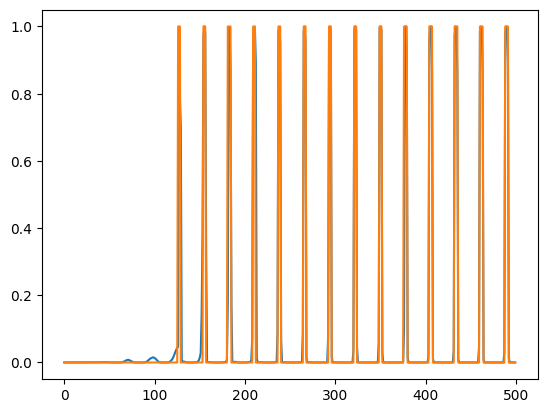

In [20]:
plt.plot(jax.nn.sigmoid(logits).flatten())
plt.plot(inputs[:1,:500].flatten())

In [21]:

def naive_autoregressive_decoding(key, T=784):
    x = jnp.zeros((1, T), dtype=jnp.bool_)
    def scan_fn(carry, k):
        x, i = carry
        logits = model(x.astype(jnp.int32))
        p_i = jax.nn.sigmoid(logits[0,i]).squeeze(-1)
        #jax.debug.print("p={p}", p=p_i)
        x_i = jax.random.bernoulli(k, p_i)
        x = x.at[0, i].set(x_i)
        return (x, i+1), None
    keys = jrandom.split(key, (T,))
    x, _ = jax.lax.scan(scan_fn, (x, 0), keys)
    
    return x[0].squeeze(0)

In [31]:
keys = jrandom.split(jrandom.PRNGKey(0), 100)

In [32]:
samples = jax.vmap(naive_autoregressive_decoding)(keys)

In [37]:
img = samples.reshape(10, 10, 28, 28).transpose(0, 2, 1, 3).reshape(10*28, 10*28)

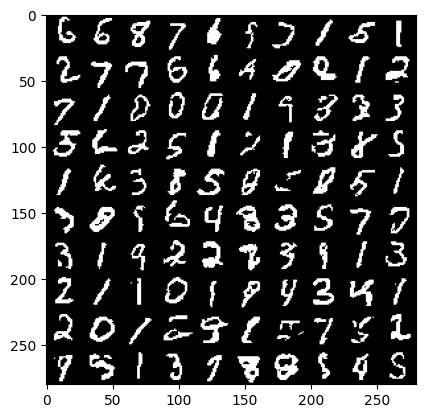

In [38]:
plt.imshow(img, cmap="gray")